**Post Feature Engineering Baseline Multiclass Models**

Train baseline multiclass models for next-3h risk class, evaluate with recall focus, tune High-risk threshold τ, 



In [18]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score,
    average_precision_score, mean_squared_error
)

import matplotlib.pyplot as plt
import joblib

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"
OUT_SUMMARY = MODEL_DIR / "05_baseline_post_feature_engineering_summary.csv"

In [19]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h","HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))

Shape: (1383922, 50)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [20]:
# --- Time-based split ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class","y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as feature (we already have time features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (922720, 47) (228784, 47) (232418, 47)


In [21]:
# --- Identify categorical and numeric columns ---
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")

num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Numeric:", len(num_cols), "Categorical:", len(cat_cols), cat_cols)

Numeric: 46 Categorical: 1 ['HOOD_158_CODE']


In [22]:

# --- Preprocess: impute + scale numeric, one-hot categorical ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

In [24]:
# --- Helpers for evaluation ---
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, proba=None, name="Model"):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[0,1,2])
    rec = recall_score(y_true_arr, y_pred_arr, labels=[0,1,2], average=None, zero_division=0)
    macro_rec = float(np.mean(rec))
    rec2 = recall_score((y_true_arr==2).astype(int), (y_pred_arr==2).astype(int), zero_division=0)
    prec2 = precision_score((y_true_arr==2).astype(int), (y_pred_arr==2).astype(int), zero_division=0)

    print(f"\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round(rec, 4))
    print("Macro recall:", round(float(macro_rec), 4))
    print("High-risk recall:", round(float(rec2), 4))
    print("High-risk precision:", round(float(prec2), 4))
    print("\n", classification_report(y_true_arr, y_pred_arr, digits=4, zero_division=0))
    plot_confusion(cm, title=f"{name} Confusion Matrix")

    row = {
        "model": name,
        "macro_recall": macro_rec,
        "recall_0": float(rec[0]),
        "recall_1": float(rec[1]),
        "recall_2": float(rec[2]),
        "precision_2": float(prec2),
        "ap_class2": np.nan,
        "macro_map": np.nan,
        "prob_rmse_macro": np.nan,
    }

    if proba is not None:
        proba_arr = np.asarray(proba)

        ap_vals = []
        for cls in [0, 1, 2]:
            y_bin = (y_true_arr == cls).astype(int)
            if y_bin.sum() > 0:
                ap = float(average_precision_score(y_bin, proba_arr[:, cls]))
                row[f"ap_class{cls}"] = ap
                ap_vals.append(ap)
            else:
                row[f"ap_class{cls}"] = np.nan

        row["ap_class2"] = row.get("ap_class2", np.nan)
        row["macro_map"] = float(np.mean(ap_vals)) if len(ap_vals) else np.nan

        y_onehot = np.zeros((len(y_true_arr), 3), dtype=float)
        y_onehot[np.arange(len(y_true_arr)), y_true_arr.astype(int)] = 1.0
        row["prob_rmse_macro"] = float(np.mean([
            np.sqrt(mean_squared_error(y_onehot[:, c], proba_arr[:, c]))
            for c in range(3)
        ]))

    return row

def apply_two_thresholds(proba, tau1, tau2):
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2
    return pred

def tune_two_thresholds(
    proba_val, y_val,
    tau1_grid=np.linspace(0.20, 0.70, 11),
    tau2_grid=np.linspace(0.05, 0.40, 15),
    min_recall_1=0.25,
    max_pred2_rate=0.15
):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec2 = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec2 = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec2, prec2, pred2_rate))

    df = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])

    feasible = df[(df["recall_1"] >= min_recall_1) & (df["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]

    return float(best["tau1"]), float(best["tau2"]), df


=== Dummy (Most Frequent) - Val ===
Per-class recall [0,1,2]: [1. 0. 0.]
Macro recall: 0.3333
High-risk recall: 0.0
High-risk precision: 0.0

               precision    recall  f1-score   support

           0     0.8951    1.0000    0.9447    204791
           1     0.0000    0.0000    0.0000     20758
           2     0.0000    0.0000    0.0000      3235

    accuracy                         0.8951    228784
   macro avg     0.2984    0.3333    0.3149    228784
weighted avg     0.8013    0.8951    0.8456    228784



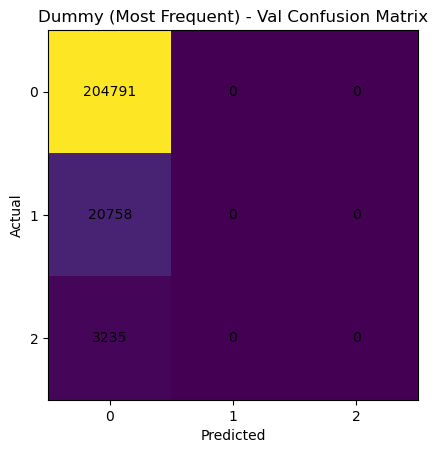


=== Dummy (Most Frequent) - Test ===
Per-class recall [0,1,2]: [1. 0. 0.]
Macro recall: 0.3333
High-risk recall: 0.0
High-risk precision: 0.0

               precision    recall  f1-score   support

           0     0.8942    1.0000    0.9441    207818
           1     0.0000    0.0000    0.0000     21189
           2     0.0000    0.0000    0.0000      3411

    accuracy                         0.8942    232418
   macro avg     0.2981    0.3333    0.3147    232418
weighted avg     0.7995    0.8942    0.8442    232418



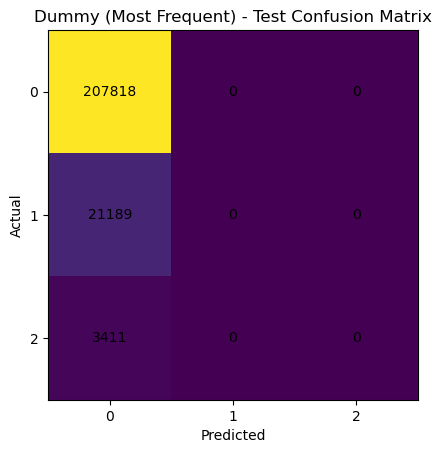

{'model': 'Dummy (Most Frequent) - Test',
 'macro_recall': 0.3333333333333333,
 'recall_0': 1.0,
 'recall_1': 0.0,
 'recall_2': 0.0,
 'precision_2': 0.0,
 'ap_class2': 0.014676143844280563,
 'macro_map': 0.3333333333333333,
 'prob_rmse_macro': 0.24947377986225094,
 'ap_class0': 0.8941562185372905,
 'ap_class1': 0.09116763761842886}

In [25]:




# --- Baseline 1: Dummy (most frequent) ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred_val = dummy.predict(X_val)
eval_multiclass(y_val, pred_val, dummy.predict_proba(X_val), name="Dummy (Most Frequent) - Val")
pred_test_dummy = dummy.predict(X_test)
eval_multiclass(y_test, pred_test_dummy, dummy.predict_proba(X_test), name="Dummy (Most Frequent) - Test")


=== LogReg Argmax - Val ===
Per-class recall [0,1,2]: [0.6547 0.3466 0.6065]
Macro recall: 0.5359
High-risk recall: 0.6065
High-risk precision: 0.06

               precision    recall  f1-score   support

           0     0.9519    0.6547    0.7758    204791
           1     0.1303    0.3466    0.1894     20758
           2     0.0600    0.6065    0.1092      3235

    accuracy                         0.6261    228784
   macro avg     0.3807    0.5359    0.3581    228784
weighted avg     0.8648    0.6261    0.7132    228784



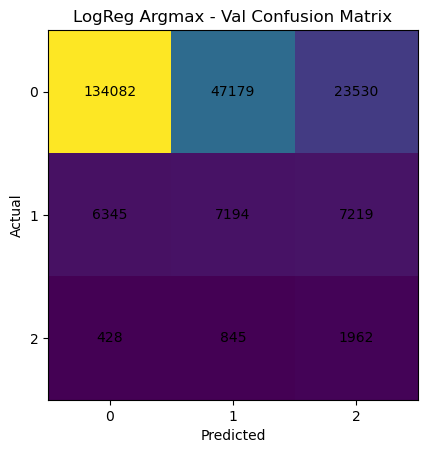


=== LogReg Argmax - Test ===
Per-class recall [0,1,2]: [0.6379 0.3326 0.6725]
Macro recall: 0.5477
High-risk recall: 0.6725
High-risk precision: 0.0615

               precision    recall  f1-score   support

           0     0.9543    0.6379    0.7646    207818
           1     0.1253    0.3326    0.1820     21189
           2     0.0615    0.6725    0.1127      3411

    accuracy                         0.6105    232418
   macro avg     0.3804    0.5477    0.3531    232418
weighted avg     0.8657    0.6105    0.7020    232418



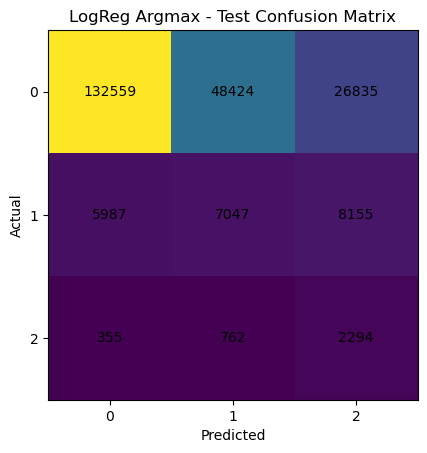

Chosen thresholds (LogReg): {'tau1': 0.35, 'tau2': 0.4}


,tau1,tau2,macro_recall,recall_1,recall_2,precision_2,pred2_rate
71,0.40,0.325,0.529831,0.203343,0.720247,0.047844,0.212865
58,0.35,0.375,0.529251,0.419164,0.645750,0.056596,0.161336
73,0.40,0.375,0.529228,0.257106,0.645750,0.056596,0.161336
72,0.40,0.350,0.529070,0.229839,0.681607,0.051880,0.185773
59,0.35,0.400,0.528412,0.455343,0.605564,0.061307,0.139669
57,0.35,0.350,0.527215,0.378746,0.681607,0.051880,0.185773
56,0.35,0.325,0.526891,0.341170,0.720247,0.047844,0.212865
70,0.40,0.300,0.526640,0.173331,0.751468,0.043710,0.243098
74,0.40,0.400,0.526505,0.280181,0.605564,0.061307,0.139669
69,0.40,0.275,0.522851,0.143029,0.783308,0.040013,0.276811



=== LogReg Two-Threshold (tau1=0.35, tau2=0.40) - Test ===
Per-class recall [0,1,2]: [0.5127 0.4385 0.6722]
Macro recall: 0.5411
High-risk recall: 0.6722
High-risk precision: 0.0635

               precision    recall  f1-score   support

           0     0.9637    0.5127    0.6693    207818
           1     0.1084    0.4385    0.1738     21189
           2     0.0635    0.6722    0.1160      3411

    accuracy                         0.5083    232418
   macro avg     0.3785    0.5411    0.3197    232418
weighted avg     0.8725    0.5083    0.6160    232418



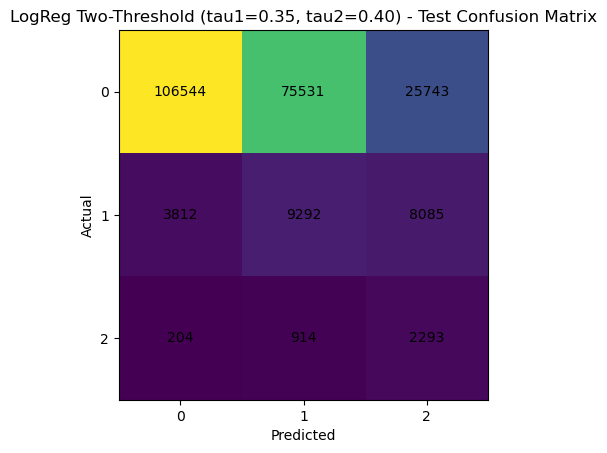

Predicted class-2 rate: 0.155413952447745


In [26]:
# --- Baseline 2: Logistic Regression (convergence fix) ---
logreg = LogisticRegression(
    solver="saga",
    max_iter=2000,
    tol=1e-3,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)


logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

logreg_pipe.fit(X_train, y_train)

pred_val = logreg_pipe.predict(X_val)
eval_multiclass(y_val, pred_val, logreg_pipe.predict_proba(X_val), name="LogReg Argmax - Val")

pred_test = logreg_pipe.predict(X_test)
eval_multiclass(y_test, pred_test, logreg_pipe.predict_proba(X_test), name="LogReg Argmax - Test")

# --- Two-threshold tuning (Val) -> apply on Test ---
proba_val = logreg_pipe.predict_proba(X_val)
tau1, tau2, grid = tune_two_thresholds(proba_val, y_val, min_recall_1=0.25, max_pred2_rate=0.15)
print("Chosen thresholds (LogReg):", {"tau1": tau1, "tau2": tau2})
display(grid.sort_values(["macro_recall","recall_2","precision_2"], ascending=False).head(10))

pred_test_thr = apply_two_thresholds(logreg_pipe.predict_proba(X_test), tau1, tau2)
eval_multiclass(y_test, pred_test_thr, logreg_pipe.predict_proba(X_test), name=f"LogReg Two-Threshold (tau1={tau1:.2f}, tau2={tau2:.2f}) - Test")
print("Predicted class-2 rate:", float((pred_test_thr==2).mean()))



=== 05 Dummy Most Frequent - Test ===
Per-class recall [0,1,2]: [1. 0. 0.]
Macro recall: 0.3333
High-risk recall: 0.0
High-risk precision: 0.0

               precision    recall  f1-score   support

           0     0.8942    1.0000    0.9441    207818
           1     0.0000    0.0000    0.0000     21189
           2     0.0000    0.0000    0.0000      3411

    accuracy                         0.8942    232418
   macro avg     0.2981    0.3333    0.3147    232418
weighted avg     0.7995    0.8942    0.8442    232418



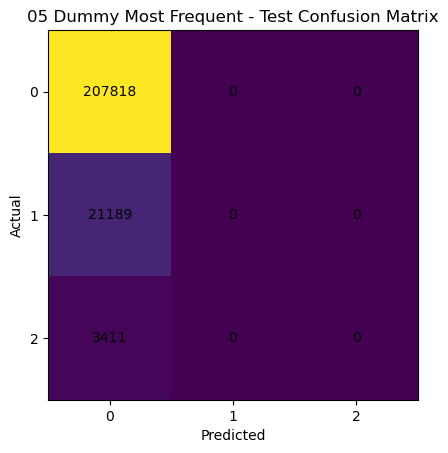


=== 05 LogReg Argmax - Test ===
Per-class recall [0,1,2]: [0.6379 0.3326 0.6725]
Macro recall: 0.5477
High-risk recall: 0.6725
High-risk precision: 0.0615

               precision    recall  f1-score   support

           0     0.9543    0.6379    0.7646    207818
           1     0.1253    0.3326    0.1820     21189
           2     0.0615    0.6725    0.1127      3411

    accuracy                         0.6105    232418
   macro avg     0.3804    0.5477    0.3531    232418
weighted avg     0.8657    0.6105    0.7020    232418



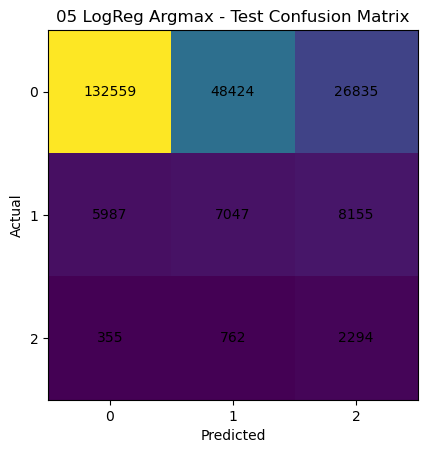


=== 05 LogReg Two-Threshold - Test ===
Per-class recall [0,1,2]: [0.5127 0.4385 0.6722]
Macro recall: 0.5411
High-risk recall: 0.6722
High-risk precision: 0.0635

               precision    recall  f1-score   support

           0     0.9637    0.5127    0.6693    207818
           1     0.1084    0.4385    0.1738     21189
           2     0.0635    0.6722    0.1160      3411

    accuracy                         0.5083    232418
   macro avg     0.3785    0.5411    0.3197    232418
weighted avg     0.8725    0.5083    0.6160    232418



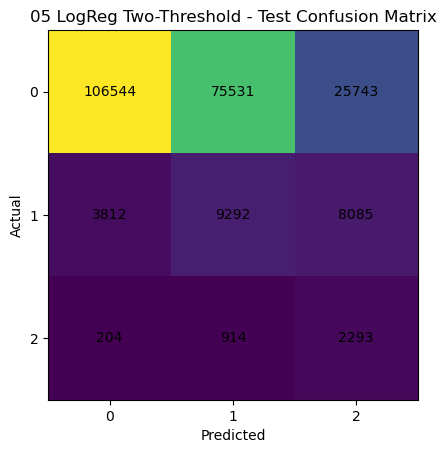

Saved: ../models/05_baseline_post_feature_engineering_summary.csv


,model,macro_recall,recall_2,precision_2,ap_class2,macro_map,prob_rmse_macro
0,05 Dummy Most Frequent - Test,0.333333,0.000000,0.000000,0.014676,0.333333,0.249474
1,05 LogReg Argmax - Test,0.547656,0.672530,0.061528,0.113842,0.398550,0.395529
2,05 LogReg Two-Threshold - Test,0.541149,0.672237,0.063481,0.113842,0.398550,0.395529


In [27]:
# --- Save compact summary ---
summary_rows = []

# Dummy baseline
dummy_proba_test = dummy.predict_proba(X_test)
summary_rows.append(
    eval_multiclass(
        y_test,
        pred_test_dummy,
        proba=dummy_proba_test,
        name="05 Dummy Most Frequent - Test"
    )
)

# LogReg argmax
proba_test = logreg_pipe.predict_proba(X_test)
summary_rows.append(
    eval_multiclass(
        y_test,
        pred_test,
        proba=proba_test,
        name="05 LogReg Argmax - Test"
    )
)

# LogReg two-threshold
summary_rows.append(
    eval_multiclass(
        y_test,
        pred_test_thr,
        proba=proba_test,
        name=f"05 LogReg Two-Threshold - Test"
    )
)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[
    [c for c in [
        "model", "macro_recall", "recall_2", "precision_2",
        "ap_class2", "macro_map", "prob_rmse_macro"
    ] if c in summary_df.columns]
].copy()

summary_df.to_csv(OUT_SUMMARY, index=False)
print("Saved:", OUT_SUMMARY)
display(summary_df)